# CSE 151B — SFT training (Numina QLoRA)

QLoRA fine-tune `Qwen/Qwen3-4B-Thinking-2507` on `data/sft_corpus.jsonl` (15k Numina rows, explicit `<think>` schema).

**Workflow (Colab A100):**
1. Run `%pip` → restart runtime.
2. Mount Drive; copy `sft_corpus.jsonl` (+ manifest) if needed.
3. Set `SMOKE_MODE = True` → smoke train (≤100 steps, ≤500 rows) → inspect loss + §9 samples.
4. Set `SMOKE_MODE = False` → full 1-epoch run; checkpoints every 500 steps to Drive.
5. Eval best checkpoint in `notebooks/sft_eval.ipynb` (`LORA_PATH` → adapter dir).

Plan: [`docs/sft/pipeline.md`](../docs/sft/pipeline.md). Corpus: [`data/sft_corpus_manifest.json`](../data/sft_corpus_manifest.json).

## 1. Environment

**Colab:** run `%pip`, restart, continue. **Local:** install `torch`, `transformers`, `bitsandbytes`, `peft`, `trl`, `accelerate`, `datasets` in your venv.

In [1]:
# Colab: skip when working locally.
%pip install -q sympy numpy tqdm datasets accelerate
%pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu129 --upgrade
%pip install -q transformers "bitsandbytes>=0.48.1" peft trl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.8/647.8 MB 85.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 121.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 88.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 237.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 132.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 115.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 224.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 MB 191.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.1/338.1 MB 115.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.5/366.5 MB 112.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.7/39.7 MB 226.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━

## 2. Configuration

Toggle `SMOKE_MODE` for the first Colab session. `RUN_NAME` labels Drive checkpoints and `sft_eval` runs.

In [2]:
import json
import os
import random
import shutil
from datetime import datetime, timezone
from pathlib import Path


def _repo_root() -> Path:
    here = Path.cwd().resolve()
    if (here / "data").is_dir():
        return here
    if here.name == "notebooks" and (here.parent / "data").is_dir():
        return here.parent
    up = here.parent
    if (up / "data").is_dir():
        return up
    return here


REPO_ROOT = _repo_root()

# --- run switches ---
SMOKE_MODE = True
RUN_NAME = "numina_smoke" if SMOKE_MODE else "numina_v1"

MODEL_ID = "Qwen/Qwen3-4B-Thinking-2507"
CORPUS_PATH = REPO_ROOT / "data/sft_corpus.jsonl"
MANIFEST_PATH = REPO_ROOT / "data/sft_corpus_manifest.json"
DEV_PATH = REPO_ROOT / "data/dev.jsonl"

# Drive layout mirrors repo (see pipeline.md)
DRIVE_PROJECT_ROOT = Path("/content/drive/MyDrive/CSE151B")
OUTPUT_DIR = DRIVE_PROJECT_ROOT / "checkpoints" / RUN_NAME

# --- hyperparameters (pipeline.md) ---
LORA_R = 32
LORA_ALPHA = 64
LORA_DROPOUT = 0.05
LORA_TARGETS = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]
LEARNING_RATE = 1e-5
WARMUP_RATIO = 0.03  # converted to warmup_steps in §7 from total training steps
PER_DEVICE_BATCH = 1
GRAD_ACCUM = 16
SAVE_STEPS = 500
LOGGING_STEPS = 10

if SMOKE_MODE:
    MAX_SAMPLES = 500
    MAX_STEPS = 100
    MAX_SEQ_LENGTH = 4096
    NUM_TRAIN_EPOCHS = 1
else:
    MAX_SAMPLES = None
    MAX_STEPS = -1
    MAX_SEQ_LENGTH = 8192
    NUM_TRAIN_EPOCHS = 1

SEED = 42
GPU_ID = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID

print(f"REPO_ROOT={REPO_ROOT}")
print(f"SMOKE_MODE={SMOKE_MODE} RUN_NAME={RUN_NAME}")
print(f"OUTPUT_DIR={OUTPUT_DIR}")

REPO_ROOT=/content
SMOKE_MODE=True RUN_NAME=numina_smoke
OUTPUT_DIR=/content/drive/MyDrive/CSE151B/checkpoints/numina_smoke


## 3. Colab: Drive + corpus copy

In [18]:
try:
    from google.colab import drive
except ImportError:
    print("Skip: not Colab — use repo paths.")
else:
    drive.mount("/content/drive")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for rel in [
        "data/sft_corpus.jsonl",
        "data/sft_corpus_manifest.json",
        "data/dev.jsonl",
    ]:
        src = DRIVE_PROJECT_ROOT / rel
        dst = REPO_ROOT / rel
        if src.is_file():
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst)
            print(f"Copied {rel}")
        elif not dst.is_file():
            print(f"Warning: missing {src} and {dst}")

if not CORPUS_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {CORPUS_PATH}. Run sft_data_prep + build_sft_corpus.py first."
    )
if MANIFEST_PATH.is_file():
    _manifest = json.loads(MANIFEST_PATH.read_text())
    print(
        f"Corpus manifest: {_manifest.get('final_row_count')} rows, "
        f"thinking_template={_manifest.get('thinking_template')}"
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied data/sft_corpus.jsonl
Copied data/sft_corpus_manifest.json
Copied data/dev.jsonl
Corpus manifest: 15000 rows, thinking_template=explicit_redacted_thinking


## 4. Prompt helpers (match dev / submission / data prep)

In [4]:
from typing import Any, Optional

SYSTEM_PROMPT_MATH = (
    "You are an expert mathematician. Solve the problem step-by-step. "
    "Put your final answer inside \\boxed{}. "
    "If the problem has multiple sub-answers, separate them by commas inside a single \\boxed{}, "
    "e.g. \\boxed{3, 7}."
)

SYSTEM_PROMPT_MCQ = (
    "You are an expert mathematician. "
    "Read the problem and the answer choices below, then select the single best answer. "
    "Output ONLY the letter of your chosen option inside \\boxed{}, e.g. \\boxed{C}."
)


def build_prompt(question: str, options: Optional[list]) -> tuple[str, str]:
    if options:
        labels = [chr(65 + i) for i in range(len(options))]
        opts_text = "\n".join(f"{lbl}. {opt.strip()}" for lbl, opt in zip(labels, options))
        return SYSTEM_PROMPT_MCQ, f"{question}\n\nOptions:\n{opts_text}"
    return SYSTEM_PROMPT_MATH, question


def row_to_messages(row: dict[str, Any]) -> list[dict[str, str]]:
    system, user = build_prompt(row["question"], row.get("options"))
    return [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
        {"role": "assistant", "content": row["response"]},
    ]


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]

## 5. Build Hugging Face dataset

In [12]:
import torch
from datasets import Dataset
from transformers import AutoTokenizer

random.seed(SEED)
corpus_rows = read_jsonl(CORPUS_PATH)
random.shuffle(corpus_rows)
if MAX_SAMPLES is not None:
    corpus_rows = corpus_rows[:MAX_SAMPLES]

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# TRL assistant_only_loss needs {% generation %} markers; Thinking-2507 is not an exact
# match for get_training_chat_template(), so use the Qwen3 thinking training template.
INFERENCE_CHAT_TEMPLATE = tokenizer.chat_template
from trl.chat_template_utils import qwen3_training_chat_template

tokenizer.chat_template = qwen3_training_chat_template

records = [{"messages": row_to_messages(r)} for r in corpus_rows]
train_ds = Dataset.from_list(records)

# Drop rows that exceed max length after chat template
def _token_len(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"n_tokens": len(tokenizer.encode(text, add_special_tokens=False))}

train_ds = train_ds.map(_token_len, desc="token lengths")
before = len(train_ds)
train_ds = train_ds.filter(lambda x: x["n_tokens"] <= MAX_SEQ_LENGTH)
train_ds = train_ds.remove_columns(["n_tokens"])
print(f"Train rows: {len(train_ds)} (dropped {before - len(train_ds)} over {MAX_SEQ_LENGTH} tokens)")

token lengths:   0%|          | 0/500 [00:00<?, ? examples/s]

Filter:   0%|          | 0/500 [00:00<?, ? examples/s]

Train rows: 500 (dropped 0 over 4096 tokens)


## 6. Load 4-bit base + LoRA

In [13]:
from peft import LoraConfig
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)
model.config.use_cache = False
model.gradient_checkpointing_enable()

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGETS,
    bias="none",
    task_type="CAUSAL_LM",
)
print("Base model + LoRA config ready.")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Base model + LoRA config ready.


## 7. Train (TRL SFTTrainer, assistant-only loss)

Resumes from the latest `checkpoint-*` in `OUTPUT_DIR` when present.

In [14]:
from trl import SFTConfig, SFTTrainer

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_checkpoints = sorted(OUTPUT_DIR.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[-1]))
resume_ckpt = str(_checkpoints[-1]) if _checkpoints else None
if resume_ckpt:
    print(f"Resuming from {resume_ckpt}")

_effective_batch = PER_DEVICE_BATCH * GRAD_ACCUM
_steps_per_epoch = max(1, len(train_ds) // _effective_batch)
_total_steps = _steps_per_epoch * NUM_TRAIN_EPOCHS
if MAX_STEPS > 0:
    _total_steps = MAX_STEPS
_warmup_steps = max(1, int(_total_steps * WARMUP_RATIO))
print(f"Training steps: {_total_steps} (warmup_steps={_warmup_steps})")

training_args = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_steps=_warmup_steps,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    max_steps=MAX_STEPS if MAX_STEPS > 0 else -1,
    max_length=MAX_SEQ_LENGTH,
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    save_total_limit=3,
    bf16=True,
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    report_to="none",
    seed=SEED,
    dataset_text_field=None,
    assistant_only_loss=True,
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    processing_class=tokenizer,
    peft_config=peft_config,
)

train_result = trainer.train(resume_from_checkpoint=resume_ckpt)
print(train_result)

final_dir = OUTPUT_DIR / "final_adapter"
trainer.save_model(str(final_dir))
tokenizer.save_pretrained(str(final_dir))

run_meta = {
    "run_name": RUN_NAME,
    "smoke_mode": SMOKE_MODE,
    "model_id": MODEL_ID,
    "corpus_path": str(CORPUS_PATH),
    "train_rows": len(train_ds),
    "max_seq_length": MAX_SEQ_LENGTH,
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "learning_rate": LEARNING_RATE,
    "warmup_steps": _warmup_steps,
    "warmup_ratio": WARMUP_RATIO,
    "finished_at": datetime.now(timezone.utc).isoformat(),
    "final_adapter": str(final_dir),
}
(OUTPUT_DIR / "run_meta.json").write_text(json.dumps(run_meta, indent=2) + "\n")
print(f"Saved adapter → {final_dir}")

Training steps: 100 (warmup_steps=3)


Tokenizing train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,0.748570
20,0.727632
30,0.627392
40,0.607286
50,0.593460
60,0.608387
70,0.596230
80,0.595984
90,0.573210
100,0.545438


TrainOutput(global_step=100, training_loss=0.6223588800430297, metrics={'train_runtime': 1284.1446, 'train_samples_per_second': 1.246, 'train_steps_per_second': 0.078, 'total_flos': 3.916615027665408e+16, 'train_loss': 0.6223588800430297})
Saved adapter → /content/drive/MyDrive/CSE151B/checkpoints/numina_smoke/final_adapter


## 8. Loss curve (smoke / debug)

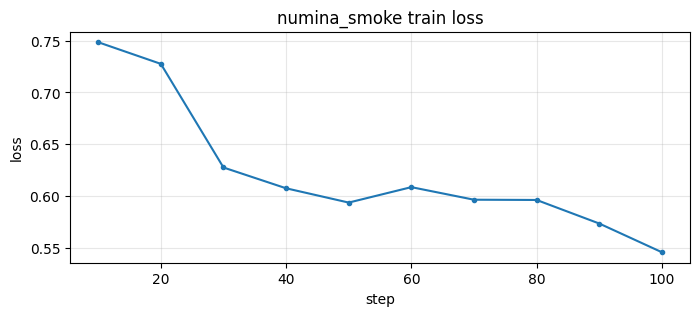

First loss=0.7486  last loss=0.5454


In [16]:
import matplotlib.pyplot as plt

log_hist = trainer.state.log_history
steps, losses = [], []
for entry in log_hist:
    if "loss" in entry and "step" in entry:
        steps.append(entry["step"])
        losses.append(entry["loss"])
if losses:
    plt.figure(figsize=(8, 3))
    plt.plot(steps, losses, marker=".")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title(f"{RUN_NAME} train loss")
    plt.grid(True, alpha=0.3)
    plt.show()
    print(f"First loss={losses[0]:.4f}  last loss={losses[-1]:.4f}")
else:
    print("No loss entries in log_history yet.")

## 9. Smoke: generate 10 dev samples

Quick qualitative check before full training. Expect `<think>` blocks and `\boxed{...}` finals. If outputs are answer-only or very short, stop and inspect schema / masking.

In [20]:
from peft import PeftModel

N_SMOKE_SAMPLES = 10
MAX_NEW_TOKENS = 2048

if not DEV_PATH.is_file():
    print(f"Skip smoke gen: {DEV_PATH} missing")
else:
    dev_rows = read_jsonl(DEV_PATH)[:N_SMOKE_SAMPLES]
    gen_model = PeftModel.from_pretrained(model, str(final_dir))
    gen_model.eval()

    for i, item in enumerate(dev_rows):
        system, user = build_prompt(item["question"], item.get("options"))
        messages = [
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ]
        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            chat_template=INFERENCE_CHAT_TEMPLATE,
        )
        inputs = tokenizer(prompt, return_tensors="pt").to(gen_model.device)
        with torch.no_grad():
            out = gen_model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=True,
                temperature=0.6,
                top_p=0.95,
                pad_token_id=tokenizer.pad_token_id,
            )
        text = tokenizer.decode(out[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True)
        has_think = "<think>" in text
        has_boxed = "\\boxed" in text
        print(f"\n--- dev id={item['id']} think={has_think} boxed={has_boxed} len={len(text)} ---")
        print(text)

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(



--- dev id=3 think=False boxed=True len=1394 ---
Okay, let's see. I need to reduce the fraction 25/40. Hmm, reducing a fraction means simplifying it to its lowest terms, right? So I need to find the greatest common divisor (GCD) of the numerator and the denominator and then divide both by that number. 

First, let me recall what the GCD is. The GCD of two numbers is the largest number that divides both of them without leaving a remainder. So I need to find the GCD of 25 and 40. 

Let me list the factors of each number to find the common ones. 

Factors of 25: 1, 5, 25. Because 25 is 5 squared, so its factors are 1, 5, 25.

Factors of 40: Let's see, 40 divided by 1 is 40, 2 is 20, 4 is 10, 5 is 8, 8 is 5, 10 is 4, 20 is 2, 40 is 1. So factors of 40 are 1, 2, 4, 5, 8, 10, 20, 40.

Now, the common factors of 25 and 40 are the numbers that appear in both lists. Let's check: 1 is in both, 5 is in both (since 5 divides 25 and 5 divides 40), but 25 is not a factor of 40 (40 divided by 25 is 

KeyboardInterrupt: 

## 10. Next steps

1. **Smoke pass:** `SMOKE_MODE=True` — loss should trend down; §9 samples should keep thinking + `\boxed{}`.
2. **Full run:** `SMOKE_MODE=False`, A100 40GB+, `MAX_SEQ_LENGTH=8192`; expect ~940 steps (15k / 16 effective batch).
3. **Eval:** `notebooks/sft_eval.ipynb` — set `LORA_PATH` to `checkpoints/<RUN_NAME>/final_adapter` (or a `checkpoint-*` dir), `SFT_RUN_NAME=<RUN_NAME>`.
4. **Submit:** if dev/public beat baseline without stop-rule violations, point `submission.ipynb` at the same adapter.